## Step 1: Load the data set

In [8]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [9]:
data = pd.read_csv(r"C:\Users\shrir\PycharmProjects\My Project #2 - Credit Risk Modeling\Assignment 1\loan_data_1248_with_missing.csv")
data

,income,loan_amount,term,credit_history,defaulted
0,60940.85475,17402.715470,60,1.0,1
1,49511.24258,6664.626123,36,0.0,0
2,63658.39369,17985.281390,60,0.0,1
3,79414.53742,21001.173770,36,1.0,0
4,47785.23925,4037.586145,36,1.0,0
...,...,...,...,...,...
1243,33734.37885,11861.633360,60,1.0,0
1244,40313.00419,13041.263070,60,NaN,0
1245,29969.07520,24661.792020,36,1.0,0
1246,52613.50243,8460.958634,60,0.0,0


In [10]:
data.head(10)

,income,loan_amount,term,credit_history,defaulted
0,60940.85475,17402.715470,60,1.0,1
1,49511.24258,6664.626123,36,0.0,0
2,63658.39369,17985.281390,60,0.0,1
3,79414.53742,21001.173770,36,1.0,0
4,47785.23925,4037.586145,36,1.0,0
5,NaN,18244.339420,36,1.0,0
6,NaN,23366.013950,60,1.0,1
7,65813.82512,8742.153888,60,1.0,0
8,43549.46105,26035.434320,36,1.0,1
9,61766.08078,18514.114060,60,1.0,0


## Step 2: Understanding data type and shape of data set

In [11]:
#use data.shape to know the no of columns and rows
data.shape

(1248, 5)

In [12]:
#to see the list of features use data.columns.tolist()
data.columns.tolist()

['income', 'loan_amount', 'term', 'credit_history', 'defaulted']

In [13]:
#use data.dtypes to know the data types. check if any of the data is other than float or int then change them for ML.
data.dtypes

income            float64
loan_amount       float64
term                int64
credit_history    float64
defaulted           int64
dtype: object

## Step 3: Pre-processing data

#### 1. Check missing values


In [14]:
#use isnull().sum() function to check the missing values in data set. it saya income column has 120, loan_amount has 122 missing fields and so on....
data.isnull().sum()

income            120
loan_amount       122
term                0
credit_history    112
defaulted           0
dtype: int64


#### 2. Mean or Median imputation for missing values

- handle missing values in numerical features using median imputation
- use .fillna() function
- The fillna() function replaces all missing (NaN) values in the DataFrame. Here, a dictionary is used to specify (Key : Value) that only the 'income' column should be updated. The median() function calculates the middle value of the non-missing income values, which is used as the replacement because it is less affected by extreme values (outliers) than the mean. This helps preserve the distribution of the income data and is a common preprocessing technique in credit risk modeling. The parameter inplace=True updates the original DataFrame directly without creating a new copy.

In [15]:
data.fillna({'income':data['income'].median()}, inplace = True)
data.fillna({'loan_amount':data['loan_amount'].median()}, inplace = True)
data.fillna({'credit_history':data['credit_history'].mode()[0]}, inplace = True)  #using mode because the credit history values are in binary like 0, 1 in this code [0] says we are replacing missing values as 0)

,income,loan_amount,term,credit_history,defaulted
0,60940.85475,17402.715470,60,1.0,1
1,49511.24258,6664.626123,36,0.0,0
2,63658.39369,17985.281390,60,0.0,1
3,79414.53742,21001.173770,36,1.0,0
4,47785.23925,4037.586145,36,1.0,0
...,...,...,...,...,...
1243,33734.37885,11861.633360,60,1.0,0
1244,40313.00419,13041.263070,60,1.0,0
1245,29969.07520,24661.792020,36,1.0,0
1246,52613.50243,8460.958634,60,0.0,0



- verifying the missing values are handled or not

In [16]:
data.isnull().sum()

income            0
loan_amount       0
term              0
credit_history    0
defaulted         0
dtype: int64

#### 3. Summary Statistics
- use .describe() to see the summary statistics of data

In [17]:
data.describe()

,income,loan_amount,term,credit_history,defaulted
count,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000
mean,52500.945298,16167.787505,48.000000,0.771635,0.414263
std,16967.161028,5541.521139,12.004811,0.419948,0.492792
min,8000.000000,1000.000000,36.000000,0.000000,0.000000
25%,41673.912892,12772.722412,36.000000,1.000000,0.000000
50%,52462.564120,16052.247335,48.000000,1.000000,0.000000
75%,62987.634440,19610.211515,60.000000,1.000000,1.000000
max,121349.166800,35158.645410,60.000000,1.000000,1.000000


## Step 4: Data Visualization (Explatory Data Analysis - EDA)

#### 1. Distribution of Numerical features

In [18]:
import seaborn as sns

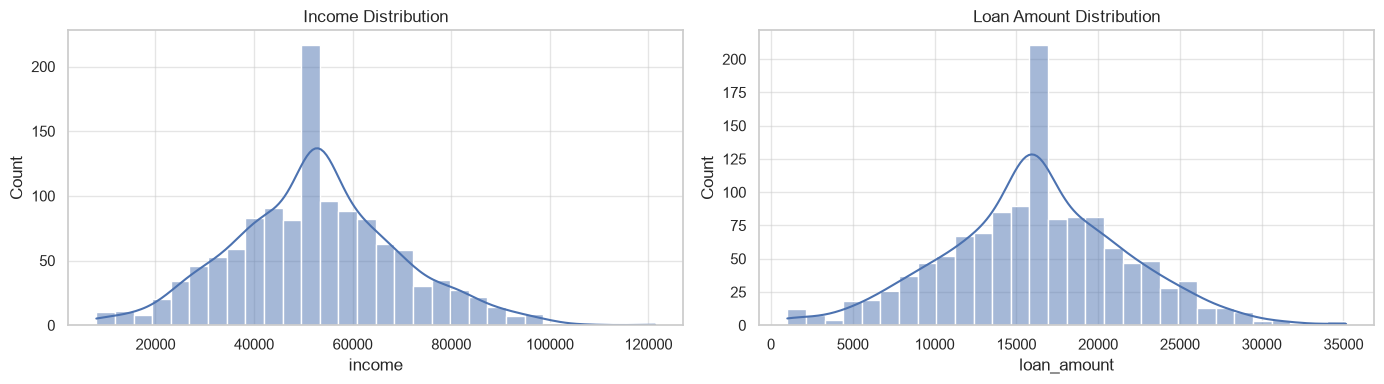

In [19]:
#set seaborn theme
sns.set(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize = (14, 4))

sns.histplot(data['income'], kde = True, bins = 30, ax = axes[0])
axes[0].set_title("Income Distribution")

sns.histplot(data['loan_amount'], kde = True, bins = 30, ax = axes[1])
axes[1].set_title("Loan Amount Distribution")

plt.tight_layout()
plt.show()

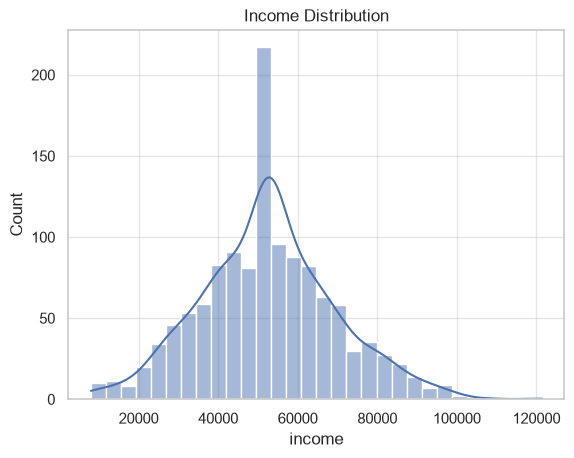

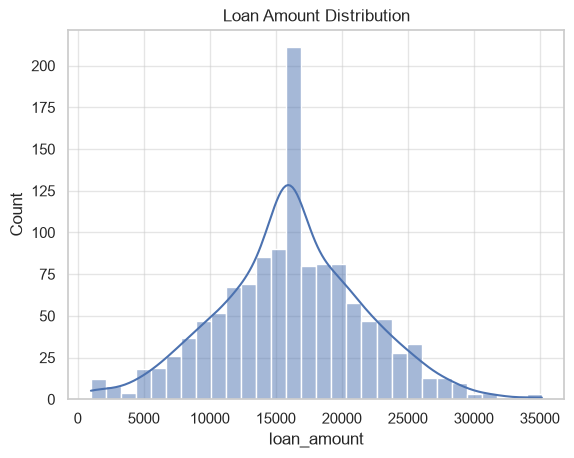

In [20]:
# simple version:
sns.histplot(data['income'], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

sns.histplot(data['loan_amount'], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

graph observation:
- The income plot has slight right skewnwss. most income are reported btw $50,000 to $70,000, with noticeable peak around $60,000.

- However, the loan amount plot is systemmetric when compared with income plot but with slight right skewness. Most of the loan amounts are clustered around $15,000 to $25,000, with peak near around $20,000.


#### 2. Loan Term Count plot.

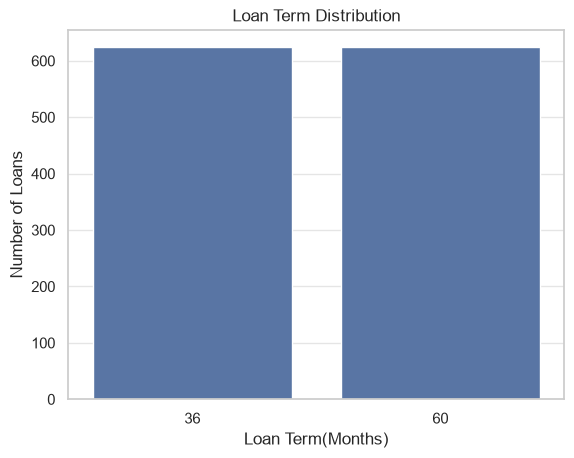

In [21]:
sns.countplot(x='term', data=data)
plt.title('Loan Term Distribution')
plt.xlabel('Loan Term(Months)')
plt.ylabel('Number of Loans')
plt.show()

observation:
there are about 600 loan in each 36 term and 60 term respectively.

#### 3. Credit History vs defaulted plot

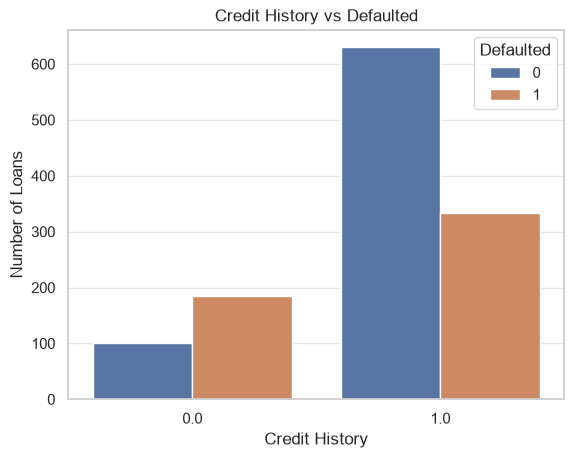

In [22]:
sns.countplot(x='credit_history', hue = 'defaulted', data =data)  #Hue in Seaborn means "use another column to split the data into different groups/colors." hue='Defaulted' → Split each category based on Defaulted.
plt.title('Credit History vs Defaulted')
plt.xlabel('Credit History')
plt.ylabel('Number of Loans')
plt.legend(title = 'Defaulted')
plt.show()

Observation:
- The 0.0 in X-axis indicates borrower with bad credit history and 1.0 indicates borrowers with good credit history.
- Majority of the people having a good credit history have not defaulted, while borrower having a bad credit history most likely defaulted.


#### 4. Correlation heatmap plot.

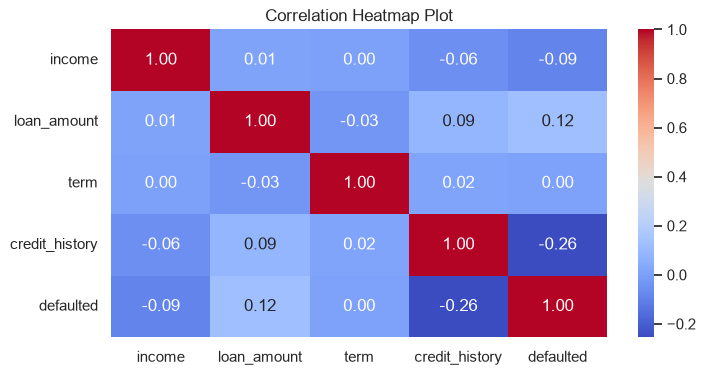

In [23]:
plt.figure(figsize = (8,4))
sns.heatmap(data.corr(numeric_only=True), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap Plot')
plt.show()

Explanation:

The correlation heatmap calculates the pairwise correlation between all numerical variables in the dataset and displays the results visually, where values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate a weak or no linear relationship; annot=True displays the correlation values on the heatmap, cmap='coolwarm' makes positive and negative relationships easier to distinguish visually, and fmt='.2f' rounds the values to two decimal places.

Key Findings in Correlation Heatmap:

| Relationship               | Correlation | Interpretation                      |
| -------------------------- | ----------: | ----------------------------------- |
| Credit history → Defaulted |   **-0.26** | Strongest relationship with default |
| Loan amount → Defaulted    |    **0.12** | Weak positive relationship          |
| Income → Defaulted         |   **-0.09** | Very weak negative relationship     |
| Term → Defaulted           |    **0.00** | Almost no linear relationship       |

So, based only on this heatmap, credit_history appears to have the strongest linear association with your default variable.

## Step 5: Feature Engineering:

#### 1. Convert Categorical Features.

In [24]:
#36 - 0 and 60 - 1
data['term_binary'] = data['term'].apply(lambda x: 1 if x==60 else 0)

#### 2. Create Derivated Features (log transformation).

we can create new features that may capture more complex patterns:

here we are converting the normal features to log features called log transformation to reduce the skewness. especially for features income and loan amount which are slightly right skewed.

In [25]:
data['log_income'] = np.log1p(data['income'])

data['log_loan_amount'] = np.log1p(data['loan_amount'])

#### 3. Feature Selection.

Final set of features for modeling.

In [26]:
features = ['log_income', 'log_loan_amount', 'credit_history']
target = 'defaulted'

## Step 6: Model Training:

#### 1. Feature Scaling.
- use standardscaler() from sklearn

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scale_features = ['log_income', 'log_loan_amount']

data[scale_features] = scaler.fit_transform(data[scale_features])
data.head()

,income,loan_amount,term,credit_history,defaulted,term_binary,log_income,log_loan_amount
0,60940.85475,17402.715470,60,1.0,1,1,0.555865,0.335135
1,49511.24258,6664.626123,36,0.0,0,0,0.010029,-1.753786
2,63658.39369,17985.281390,60,0.0,1,1,0.670515,0.406800
3,79414.53742,21001.173770,36,1.0,0,0,1.251689,0.744209
4,47785.23925,4037.586145,36,1.0,0,0,-0.083218,-2.844410


Import StandardScaler from Scikit-learn to standardize the selected numerical features, create a scaler object, select the log_income and log_loan_amount columns, use fit_transform() to calculate the mean and standard deviation of each feature and transform their values using (value - mean) / standard deviation so that they are placed on a comparable scale, replace the original values in those columns with the standardized values, and finally use head() to display the first five rows and verify the transformation.

StandardScaler transforms each variable so that it has approximately,
Mean = 0
Standard deviation = 1

Why we need to put them in comparable scale?

The main reason is not that the data needs to have the same units, but that some machine-learning algorithms can be influenced by the size of the numbers.
Now the model can focus more on where the observation sits relative to the distribution of that variable, rather than simply being influenced by the variable's original units or magnitude

#### 2. Train Split Test
- use 80-20 split -- 80% to train the model and 20% to test them using scikit-learn's train_test_split function
- random_state function helps us get the same training/testing split every time, making your results reproducible. random_state = lock the random selection so you get the same result every time. the number 42 does not hold any value it can any number like 10, 50, 100 etc.

In [28]:
from sklearn.model_selection import train_test_split

X=data[features]
y=data[target]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [29]:
"""
- The train_test_split() function divides the dataset into training and testing subsets, where X contains the borrower and loan characteristics used as input features and y contains the target variable (default outcome);
- test_size=0.2 reserves 20% of the observations for testing and 80% for training,
- while random_state=42 ensures that the random split remains consistent every time the code is executed,
- producing X_train (Contains the features for the training dataset) and y_train (Contains the actual default outcomes corresponding to X_train)for model training and X_test (Contains the features for the testing dataset) and y_test (Contains the actual default outcomes corresponding to X_test) for evaluating the model's performance on unseen data.
"""

"\n- The train_test_split() function divides the dataset into training and testing subsets, where X contains the borrower and loan characteristics used as input features and y contains the target variable (default outcome);\n- test_size=0.2 reserves 20% of the observations for testing and 80% for training,\n- while random_state=42 ensures that the random split remains consistent every time the code is executed,\n- producing X_train (Contains the features for the training dataset) and y_train (Contains the actual default outcomes corresponding to X_train)for model training and X_test (Contains the features for the testing dataset) and y_test (Contains the actual default outcomes corresponding to X_test) for evaluating the model's performance on unseen data.\n"

#### 3. Build Model Pipeline.

to build our credit scoring moodel, we use 3 different classification algorithms:
- Logistic Regression for its interpretability and baseline performance
- Decision Tree Classifier for its ability to capture non-linear relationships
- Random Forest Classifier for robustness and imporved generalization

we use scikit learn's pipeline to stremline model creation, training and prediction. This ensures our workflow remains clean and modular.

In [30]:
#import necessary modules for sklearn
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


In [31]:
from sklearn.linear_model import LogisticRegression

models = {
    'LogisticRegression': LogisticRegression(max_iter = 1000, random_state = 42),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state = 42),
    'RandomForestClassifier': RandomForestClassifier(n_estimators = 100, random_state = 42)
}

In [32]:
# Import LogisticRegression from Scikit-learn and create a dictionary containing three classification models—Logistic Regression, Decision Tree, and Random Forest—for predicting loan default; max_iter=1000 gives Logistic Regression more iterations to reach convergence, n_estimators=100 creates 100 decision trees within the Random Forest, and random_state=42 ensures that the models' random processes are reproducible so that results can be consistently compared across different model runs.

In [33]:
for name, model in models.items():
    print(f"\nModel: {name}")
    pipeline = Pipeline([('Classifier', model)])
    pipeline.fit(X_train, y_train)

    y_pred =pipeline.predict(X_test)
    print(f"Accuracy:{accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))


Model: LogisticRegression
Accuracy:0.6520
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.86      0.74       143
           1       0.67      0.37      0.48       107

    accuracy                           0.65       250
   macro avg       0.66      0.62      0.61       250
weighted avg       0.66      0.65      0.63       250


Model: DecisionTreeClassifier
Accuracy:0.5400
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.62      0.60       143
           1       0.46      0.44      0.45       107

    accuracy                           0.54       250
   macro avg       0.53      0.53      0.53       250
weighted avg       0.54      0.54      0.54       250


Model: RandomForestClassifier
Accuracy:0.6080
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.72      0.68       143
           1       0.55      0.

## Recommendation:

- Logistic Regression currently provides the best balance between simplicity and predictive power on this dataset.
- However, recall on all defaulters is low for all models. Since missing defaulters can be costly in credit scoring, you may need to:
  -  try resampling techniques (e.g., SMOTE, Class weighting).
  -  perform hyperparameter tuning
  -  explore other classifiers (eg., XGBoost, LightGBM).
  -  use threshold adjustment to favor identifying more defaulters.

In [34]:
"""
# Step 1: Loop through each model stored in the models dictionary.

# Step 2: Print the name of the current model being evaluated.

# Step 3: Create a Pipeline containing the current classification model.

# Step 4: Train the model using X_train (input features) and y_train (actual default outcomes).

# Step 5: Use the trained model to make predictions on the unseen X_test data.

# Step 6: Store the predicted default outcomes in y_pred.

# Step 7: Compare y_pred with y_test to calculate the model's accuracy.

# Step 8: Generate a classification report showing precision, recall, F1-score, and support.

# Step 9: Use these evaluation metrics to assess how well the model distinguishes between defaulted and non-defaulted loans.
"""

"\n# Step 1: Loop through each model stored in the models dictionary.\n\n# Step 2: Print the name of the current model being evaluated.\n\n# Step 3: Create a Pipeline containing the current classification model.\n\n# Step 4: Train the model using X_train (input features) and y_train (actual default outcomes).\n\n# Step 5: Use the trained model to make predictions on the unseen X_test data.\n\n# Step 6: Store the predicted default outcomes in y_pred.\n\n# Step 7: Compare y_pred with y_test to calculate the model's accuracy.\n\n# Step 8: Generate a classification report showing precision, recall, F1-score, and support.\n\n# Step 9: Use these evaluation metrics to assess how well the model distinguishes between defaulted and non-defaulted loans.\n"